In [14]:
import pandas as pd

import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error

from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt

import seaborn as sns

import statsmodels.api as sm


In [15]:
# Load the dataset
df=pd.read_csv('CarPrice_Assignment.csv')

df.head()

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [16]:
# Select features and target
X = df[['enginesize', 'horsepower', 'citympg', 'highwaympg']] # Numerical features
y = df['price']

In [17]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=8, random_state=42)


In [18]:
# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # Use X_train, not x_train
X_test_scaled = scaler.transform(X_test)


In [19]:
# Train model
model = LinearRegression()
model.fit(X_train_scaled, y_train)


LinearRegression()

In [20]:

# Predictions
y_pred= model.predict(X_test_scaled)


In [21]:
# Model coefficients and metrics
# print("="*50)
print('Name: MAHASHREE S ')

print('Reg.No: 212225230163 ')

print("MODEL COEFFICIENTS:")

for feature, coef in zip(X.columns, model.coef_):

    print(f"{feature:>12} {coef:>10.2f}")

print(f"{'Intercept':>12}: {model.intercept_:>10.2f}")


Name: MAHASHREE S 
Reg.No: 212225230163 
MODEL COEFFICIENTS:
  enginesize    4851.50
  horsepower    1861.02
     citympg      53.85
  highwaympg    -848.28
   Intercept:   13190.94


In [22]:
print("\nMODEL PERFORMANCE:")

mse=mean_squared_error(y_test,y_pred)

mase=mean_absolute_error(y_test,y_pred)

rse=np.sqrt(mse)

print(f"{'MSE':>12}: {mse:>10}")

print(f"{'MASE':>12}: {mase:>10}")

print(f"{'RMSE':>12}:{rse:>10}")

print(f"{'R-squared' : >12}: {r2_score(y_test,y_pred): >10}")


MODEL PERFORMANCE:
         MSE: 8436931.954436783
        MASE: 2081.7721186284425
        RMSE:2904.639728853956
   R-squared: 0.8888645068097022


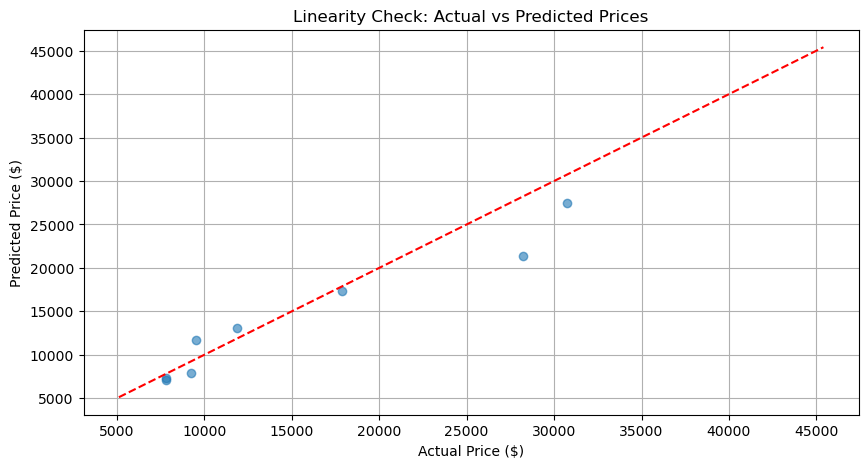

In [40]:
# 1. Linearity check
plt.figure(figsize=(10,5))
plt.scatter(y_test, y_pred, alpha=0.6)

plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')

plt.title("Linearity Check: Actual vs Predicted Prices")

plt.xlabel("Actual Price ($)")

plt.ylabel("Predicted Price ($)")

plt.grid(True)

plt.show()

In [23]:
#2. Independence (Durbin-Watson)

residuals = y_test - y_pred

dw_test = sm.stats.durbin_watson(residuals)

print(f"\nDurbin-Watson Statistic: {dw_test:.2f}",
      "\n Values close to 2 indicates no autocorrelation")


Durbin-Watson Statistic: 1.85 
 Values close to 2 indicates no autocorrelation


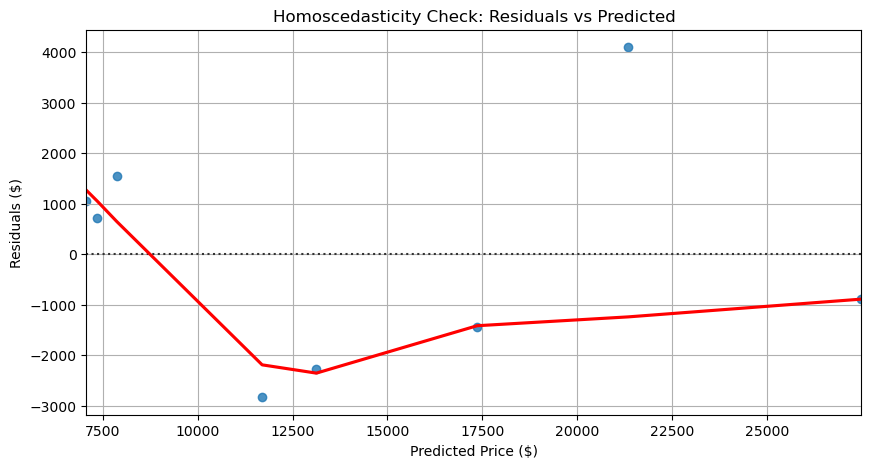

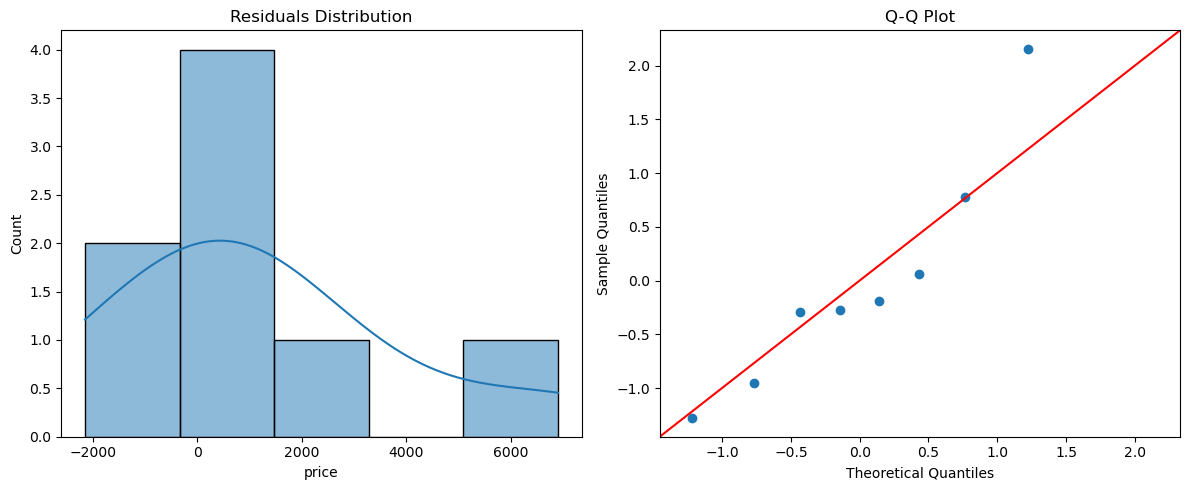

In [27]:
#3. Homoscedasticity

plt.figure(figsize=(10, 5))

sns.residplot(x=y_pred, y=residuals, lowess=True, line_kws={'color': 'red'})

plt.title("Homoscedasticity Check: Residuals vs Predicted")

plt.xlabel("Predicted Price ($)")

plt.ylabel("Residuals ($)")

plt.grid(True)

plt.show()

#4. Normality of residuals

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(residuals, kde=True, ax=ax1) 

ax1.set_title("Residuals Distribution")

sm.qqplot(residuals, line='45', fit=True, ax=ax2)

ax2.set_title("Q-Q Plot")

plt.tight_layout()

plt.show()